# Implementing and experimenting with Grover search

This notebook implements Grover search and the BBHT method and reproduces the experiments of exercise `qa-016`. The first part contains the complete implementation; the remaining parts answer items (a)–(e).

In [ ]:
# Run this cell in Google Colab.
%pip install -q qiskit qiskit-aer matplotlib

## Implementation

A truth table `f` is a string of length $N=2^n$ with `f[x]` $=f(x)$. Qubit $i$ holds bit $i$ of $x$, so Qiskit's measured bit string, read as a binary number, is $x$.

The sign oracle $O\ket x=(-1)^{f(x)}\ket x$ is synthesized by Qiskit's `PhaseOracleGate` from the disjunction of the minterms of $f$. Qiskit simplifies this expression, so the cost of the oracle depends on the marked set, and not only on $M$. Since $O_f=-O_{\bar f}$, we synthesize the less frequent value. For $M\in\{0,N\}$ the oracle is $\pm I$ and we omit it. The diffusor is $D=H^{\otimes n}\operatorname{Ref}_0H^{\otimes n}$ with $\operatorname{Ref}_0=2\ket0\bra0-I$. A multi-controlled $Z$ gate, implemented as $H$, multi-controlled $X$, $H$ on the last qubit, flips the sign of $\ket{1^n}$. Conjugating it by $X^{\otimes n}$ gives $X^{\otimes n}C^{n-1}Z\,X^{\otimes n}=I-2\ket0\bra0=-\operatorname{Ref}_0$, so the circuit implements $-D$. The sign is a global phase and does not change any measurement probabilities.

In [2]:
import math, random
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import PhaseOracleGate
from qiskit.quantum_info import Operator, Statevector
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

rng = random.Random(16016)

def oracle(f):
    n = len(f).bit_length() - 1
    if f.count("1") > len(f) // 2:
        f = f.translate(str.maketrans("01", "10"))  # O_f = -O_(not f)
    qc = QuantumCircuit(n, name="O")
    if "1" in f:
        e = " | ".join(" & ".join(("" if x >> i & 1 else "~") + f"x{i}" for i in range(n))
                       for x, b in enumerate(f) if b == "1")
        qc.append(PhaseOracleGate(e, var_order=[f"x{i}" for i in range(n)]), range(n))
    return qc

def diffusor(n):
    qc = QuantumCircuit(n, name="D")
    qc.h(range(n))
    qc.x(range(n))
    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)
    qc.h(n - 1)
    qc.x(range(n))
    qc.h(range(n))
    return qc

def iteration(f):
    G = oracle(f)
    G.compose(diffusor(G.num_qubits), inplace=True)
    return G

def circuit(f, T):
    n = len(f).bit_length() - 1
    O, D = oracle(f), diffusor(n)
    qc = QuantumCircuit(n)
    qc.h(range(n))
    for _ in range(T):
        qc.barrier()  # the oracle is a black box: no optimization across its boundary
        qc.compose(O, inplace=True)
        qc.barrier()
        qc.compose(D, inplace=True)
    return qc

The noise model uses depolarizing errors $p$ on CX gates and $p/10$ on one-qubit gates. Noisy circuits are therefore transpiled to the basis $\{u,\mathrm{cx}\}$; ideal circuits are simulated directly. Since the oracle is a black box, `circuit` surrounds it by barriers, so that the transpiler cannot merge or cancel gates across its boundary. `run` returns the measured strings as integers.

In [3]:
def noise(p):
    nm = NoiseModel()
    nm.add_all_qubit_quantum_error(depolarizing_error(p / 10, 1), ["u"])
    nm.add_all_qubit_quantum_error(depolarizing_error(p, 2), ["cx"])
    return nm

compiled = {}
def transpiled(f, T):
    if (f, T) not in compiled:
        compiled[f, T] = transpile(circuit(f, T), basis_gates=["u", "cx"], optimization_level=1)
    return compiled[f, T]

def run(f, T, shots, p=None):
    if p is None:
        sim = AerSimulator()
        qc = transpile(circuit(f, T), sim)
    else:
        sim = AerSimulator(noise_model=noise(p))
        qc = transpiled(f, T).copy()
    qc.measure_all()
    r = sim.run(qc, shots=shots, memory=True, seed_simulator=rng.randrange(2**32)).result()
    return [int(s, 2) for s in r.get_memory()]

BBHT needs one measurement per trial. Instead of simulating a circuit for every trial, `measure` simulates each circuit (given by $f$, $T$ and $p$) once with 256 shots, stores the outcomes, and returns one unused outcome per call. Since shots are independent samples of the same distribution, this is equivalent to a separate run per trial. This is only an optimization by caching; it does not change the algorithm or the statistics, and removing it would only make the experiments much slower.

**Query convention.** Each Grover iteration costs one query and verifying a measured candidate costs one query, so a Grover search with $T$ iterations costs $T+1$ queries.

`bbht(f, L)` follows the BBHT algorithm of the lecture notes: the window $m$ starts at $1$ and grows by the factor $\lambda$ up to the cap $\lceil\sqrt N\rceil$, and at most $L$ trials are performed at the cap. It never receives $M$. With $L=1$ it performs one complete schedule $i=0,1,\ldots,\lceil\log_\lambda\lceil\sqrt N\rceil\rceil$; with $L=\lceil\log(1/\delta)/\log(4/3)\rceil$ it is the bounded procedure, which reports that no marked string exists (`None`) with error probability at most $\delta$.

In [4]:
pool = {}
def measure(f, T, p=None):
    if not pool.get((f, T, p)):
        pool[f, T, p] = run(f, T, 256, p)
    return pool[f, T, p].pop()

def search(f, T, p=None):
    x = measure(f, T, p)
    return (x if f[x] == "1" else None), T + 1

def bbht(f, L=1, lam=6/5, p=None):
    cap = math.ceil(math.sqrt(len(f)))
    m, q = 1, 0
    for _ in range(math.ceil(math.log(cap, lam)) + L):
        x, k = search(f, rng.randrange(math.ceil(m)), p)
        q += k
        if x is not None:
            return x, q
        m = min(lam * m, cap)
    return None, q

def budget(delta):
    return math.ceil(math.log(1 / delta) / math.log(4 / 3))

Classical random search, with and without replacement, returns the number of queries until the first marked string is found ($M\geq1$).

In [5]:
def classical(f, replace):
    N, q = len(f), 0
    xs = rng.sample(range(N), N)
    while True:
        x = rng.randrange(N) if replace else xs[q]
        q += 1
        if f[x] == "1":
            return q

Finally, some helpers: random truth tables with $M$ marked strings, the theoretical probabilities, and standard errors.

In [6]:
def table(N, M):
    S = set(rng.sample(range(N), M))
    return "".join("1" if x in S else "0" for x in range(N))

def theta(M, N):
    return math.asin(math.sqrt(M / N))

def P(T, M, N):
    return math.sin((2 * T + 1) * theta(M, N))**2

def P_window(m, M, N):
    t = theta(M, N)
    return 1/2 - math.sin(4 * m * t) / (4 * m * math.sin(2 * t))

def bernoulli(k, n):
    return k / n, math.sqrt(k / n * (1 - k / n) / n)

def mean(v):
    return np.mean(v), np.std(v, ddof=1) / math.sqrt(len(v))

## (a) Validation

The oracle must equal $\operatorname{diag}((-1)^{f(x)})$ and the diffusor $2\ket u\bra u-I$, both up to a global phase. We compare the operators for all $M$ with $n=3$.

In [7]:
def same(A, B):
    A, B = A.data, B.data if isinstance(B, Operator) else B
    k = np.unravel_index(np.argmax(abs(B)), B.shape)
    return np.allclose(A * B[k] / A[k], B)

n, N = 3, 8
u = np.full(N, 1 / math.sqrt(N))
print("diffusor:", same(Operator(diffusor(n)), 2 * np.outer(u, u) - np.eye(N)))
for M in range(N + 1):
    f = table(N, M)
    print(f, "oracle:", same(Operator(oracle(f)), np.diag([(-1)**int(b) for b in f])))

diffusor: True
00000000 oracle: True
00001000 oracle: True
00001100 oracle: True
01000011 oracle: True
10001110 oracle: True
01011011 oracle: True
11110110 oracle: True
11111011 oracle: True
11111111 oracle: True


In [8]:
iteration(table(8, 3)).draw()

┌─────────────────────┐┌───┐┌───┐          ┌───┐┌───┐     
q_0: ┤0                    ├┤ H ├┤ X ├───────■──┤ X ├┤ H ├─────
     │                     │├───┤├───┤       │  ├───┤├───┤     
q_1: ┤1 ~x0 & x1 & ~x2 ... ├┤ H ├┤ X ├───────■──┤ X ├┤ H ├─────
     │                     │├───┤├───┤┌───┐┌─┴─┐├───┤├───┤┌───┐
q_2: ┤2                    ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├
     └─────────────────────┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘

Next we compare the exact probability of a marked string after $T$ iterations, computed from the state vector, with $\sin^2((2T+1)\theta)$ for $n=4$. This covers $M=0$, $M=1$, several $1<M<N$, and $M=N$.

In [9]:
def exact(f, T):
    pr = Statevector(circuit(f, T)).probabilities()
    return sum(pr[x] for x in range(len(f)) if f[x] == "1")

N = 16
worst = max(abs(exact(f, T) - P(T, M, N))
            for M in [0, 1, 2, 3, 5, 8, 11, 16] for f in [table(N, M)] for T in range(6))
print("maximum deviation:", worst)

maximum deviation:

 1.5987211554602254e-14


Finally, we run the complete algorithms on small instances. Every returned string is verified inside `search`, so a returned $x$ is always marked. For $M=0$ the algorithms must always report `None`.

In [10]:
N = 16
for M in [0, 1, 2, 5, 8, 12, 16]:
    f = table(N, M)
    r = [bbht(f, budget(0.01)) for _ in range(100)]
    found = [x for x, _ in r if x is not None]
    assert all(f[x] == "1" for x in found)
    print(f"M={M:2}  found={len(found):3}/100  mean queries={np.mean([q for _, q in r]):.1f}")

M= 0  found=  0/100  mean queries=56.9
M= 1  found=100/100  mean queries=6.2


M= 2  found=100/100  mean queries=3.7
M= 5  found=100/100  mean queries=2.9


M= 8  found=100/100  mean queries=2.8
M=12  found=100/100  mean queries=2.4
M=16  found=100/100  mean queries=1.0


## (b) Probability landscape

We use $n=6$, $N=64$, and for each $M$ one random truth table (in the ideal case the identity of the marked strings is irrelevant). Each point is estimated from 1000 shots.

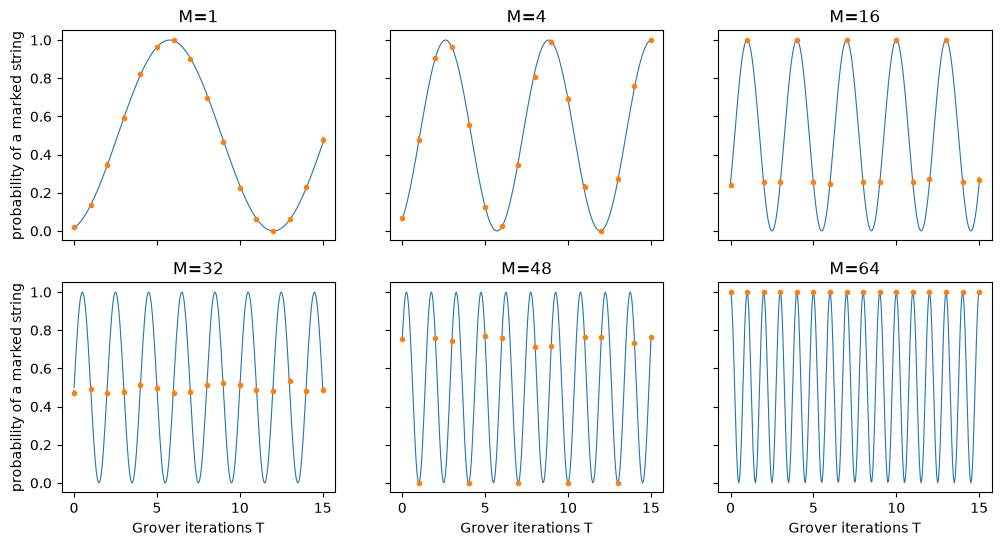

In [11]:
N, shots, Ts = 64, 1000, range(16)
curves = {}
for M in [1, 4, 16, 32, 48, 64]:
    f = table(N, M)
    curves[M] = [bernoulli(sum(f[x] == "1" for x in run(f, T, shots)), shots) for T in Ts]

fig, ax = plt.subplots(2, 3, figsize=(12, 6), sharex=True, sharey=True)
t = np.linspace(0, Ts[-1], 300)
for a, (M, c) in zip(ax.flat, curves.items()):
    a.plot(t, np.sin((2 * t + 1) * theta(M, N))**2, lw=0.8)
    a.errorbar(Ts, [r for r, _ in c], yerr=[s for _, s in c], fmt="o", ms=3)
    a.set_title(f"M={M}")
for a in ax[1]:
    a.set_xlabel("Grover iterations T")
for a in ax[:, 0]:
    a.set_ylabel("probability of a marked string")
plt.show()

The measurements follow $\sin^2((2T+1)\theta)$ within their standard errors. Since each iteration rotates the state by $2\theta$ in the Grover plane, the probability oscillates with period $\pi/(2\theta)$ in $T$.

- $M=1$: $\theta=\arcsin(1/8)\approx0.125$, and the best number of iterations is $T=6$, with probability $\approx0.997$. With too few iterations, e.g. $T=3$, the state has not yet reached $\ket m$ (probability $\approx0.6$). With too many, the state overshoots, and at $T=12$ it is almost orthogonal to $\ket m$.
- $M=4$ and $M=16$: the oscillation is faster. For $M=16$ we have $\theta=\pi/6$, so a single iteration reaches $\ket m$ exactly.
- $M=32=N/2$: $\theta=\pi/4$, and $(2T+1)\pi/4$ always gives probability $1/2$. Grover iterations do not help at all.
- $M=48>N/2$: $\theta=\pi/3$. Measuring the uniform state ($T=0$) succeeds with probability $3/4$, but $T=1$ rotates the state to angle $\pi$, i.e. onto $-\ket{\overline m}$, and the probability drops to $0$. For $M\geq N/2$ the best choice is $T=0$.
- $M=64=N$: every string is marked and the probability is always $1$.

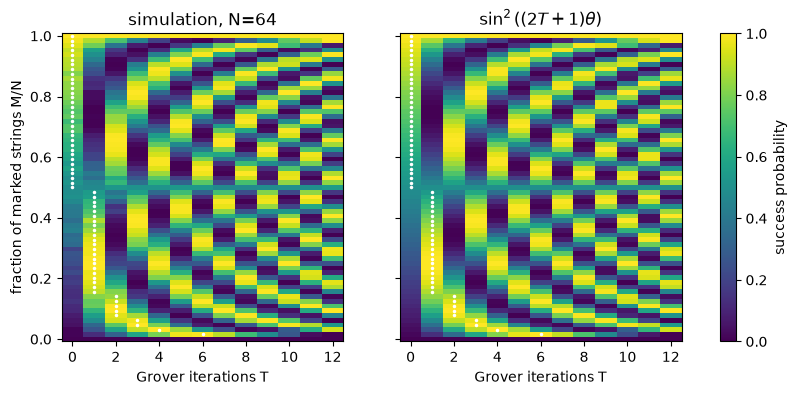

maximum deviation from the formula: 0.10381622314453098


In [12]:
shots, Ts, Ms = 200, range(13), range(N + 1)
H = np.array([[np.mean([f[x] == "1" for x in run(f, T, shots)]) for T in Ts]
              for M in Ms for f in [table(N, M)]])
Hth = np.array([[P(T, M, N) for T in Ts] for M in Ms])

fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for a, Z, title in zip(ax, [H, Hth], [f"simulation, N={N}", r"$\sin^2((2T+1)\theta)$"]):
    im = a.imshow(Z, origin="lower", aspect="auto", vmin=0, vmax=1, cmap="viridis",
                  extent=(-0.5, Ts[-1] + 0.5, -0.5 / N, 1 + 0.5 / N))
    a.plot([math.ceil(math.pi / (4 * theta(M, N)) - 1) if M else None for M in Ms], [M / N for M in Ms], "w.", ms=3)
    a.set_title(title)
    a.set_xticks(Ts[::2])
    a.set_xlabel("Grover iterations T")
ax[0].set_ylabel("fraction of marked strings M/N")
fig.colorbar(im, ax=ax, label="success probability")
plt.show()
print("maximum deviation from the formula:", np.abs(H - Hth).max())

The white dots mark the number of iterations $T=\lceil\pi/(4\theta)-1\rceil$ from the lecture notes. The simulation is ideal; the differences to the formula are due only to finite sampling. With 200 shots per cell, the Bernoulli standard error is $\sqrt{P(1-P)/200}\leq\sqrt{0.25/200}\approx0.035$, and the largest deviation over the 845 cells, about $0.10$ or three standard errors, is consistent with this.

The heat map shows that the good choices of $T$ lie along a narrow band that moves quickly to small $T$ as $M$ grows: for $M/N\geq\sin^2(\pi/8)\approx0.15$ the optimum is $T=1$, and for $M/N\geq1/2$ it is $T=0$. A fixed $T$ that is good for one $M$ is bad for others. For example, the column $T=6$, optimal for $M=1$, contains several dark stripes. For large $T$ the stripes become narrow, so without knowing $M$ we cannot guess a good $T$. This is the motivation for BBHT.

## (c) Unknown number of marked strings

### Randomized trials

For a window $m$, a randomized trial chooses $T\sim U[0,m)$. Its success probability is $1/2-\sin(4m\theta)/(4m\sin(2\theta))$, which is at least $1/4$ once $m\geq m_*=1/\sin(2\theta)$. We estimate it from 1000 randomized trials per window, for $N=256$.

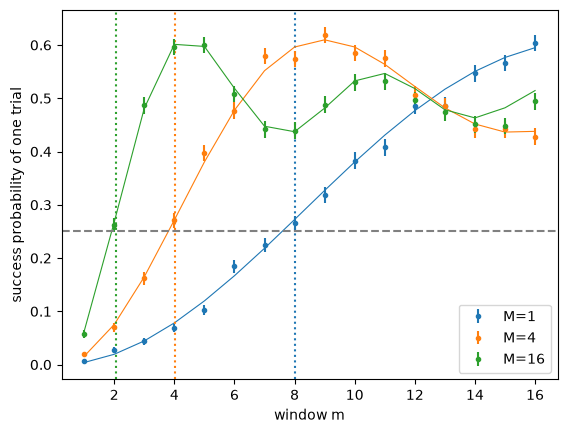

In [13]:
N, trials = 256, 1000
for M, color in zip([1, 4, 16], plt.cm.tab10.colors):
    f = table(N, M)
    ms = range(1, 17)
    est = [bernoulli(sum(search(f, rng.randrange(m))[0] is not None for _ in range(trials)), trials) for m in ms]
    plt.errorbar(ms, [r for r, _ in est], yerr=[s for _, s in est], fmt="o", ms=3, color=color, label=f"M={M}")
    plt.plot(ms, [P_window(m, M, N) for m in ms], color=color, lw=0.8)
    plt.axvline(1 / math.sin(2 * theta(M, N)), color=color, ls=":")
plt.axhline(1 / 4, color="gray", ls="--")
plt.xlabel("window m")
plt.ylabel("success probability of one trial")
plt.legend()
plt.show()

The estimates agree with $1/2-\sin(4m\theta)/(4m\sin(2\theta))$. The dotted lines mark $m_*=1/\sin(2\theta)$. For $m<m_*$ the success probability can be small (for $M=1$ and $m=4$ it is below $0.1$), but these trials are cheap. Once $m\geq m_*$, the curve stays above $1/4$ and oscillates around $1/2$, with decreasing amplitude, since averaging over $T\sim U[0,m)$ smooths out the oscillation of the previous plots. The threshold $m_*\leq\sqrt N$ is always reached by the capped window.

### Complete BBHT

For several $N$ and $M$ we sample 10 truth tables and run 50 searches on each. We estimate the probability that one complete schedule ($L=1$) finds a marked string, and the mean number of queries until BBHT succeeds ($L=\infty$).

In [14]:
tables, runs = 10, 50
results = []
for N in [16, 64, 256]:
    for M in [1, 2, 4, 8, 16]:
        fs = [table(N, M) for _ in range(tables)]
        s = bernoulli(sum(bbht(f, 1)[0] is not None for f in fs for _ in range(runs)), tables * runs)
        q = mean([bbht(f, 10**9)[1] for f in fs for _ in range(runs)])
        results.append((N, M, s, q))
        print(f"N={N:3} M={M:2}  schedule success={s[0]:.3f}±{s[1]:.3f}  queries={q[0]:6.2f}±{q[1]:.2f}  sqrt(N/M)={math.sqrt(N/M):5.2f}")

N= 16 M= 1  schedule success=0.992±0.004  queries=  5.75±0.15  sqrt(N/M)= 4.00


N= 16 M= 2  schedule success=0.998±0.002  queries=  4.02±0.10  sqrt(N/M)= 2.83


N= 16 M= 4  schedule success=1.000±0.000  queries=  2.80±0.08  sqrt(N/M)= 2.00


N= 16 M= 8  schedule success=0.998±0.002  queries=  2.59±0.11  sqrt(N/M)= 1.41
N= 16 M=16  schedule success=1.000±0.000  queries=  1.00±0.00  sqrt(N/M)= 1.00


N= 64 M= 1  schedule success=0.990±0.004  queries= 12.79±0.31  sqrt(N/M)= 8.00


...

N=256 M= 1  schedule success=0.994±0.003  queries= 25.58±0.58  sqrt(N/M)=16.00


N=256 M= 2  schedule success=1.000±0.000  queries= 18.39±0.44  sqrt(N/M)=11.31


N=256 M= 4  schedule success=1.000±0.000  queries= 12.79±0.33  sqrt(N/M)= 8.00


N=256 M= 8  schedule success=1.000±0.000  queries=  8.34±0.21  sqrt(N/M)= 5.66


N=256 M=16  schedule success=1.000±0.000  queries=  5.80±0.19  sqrt(N/M)= 4.00


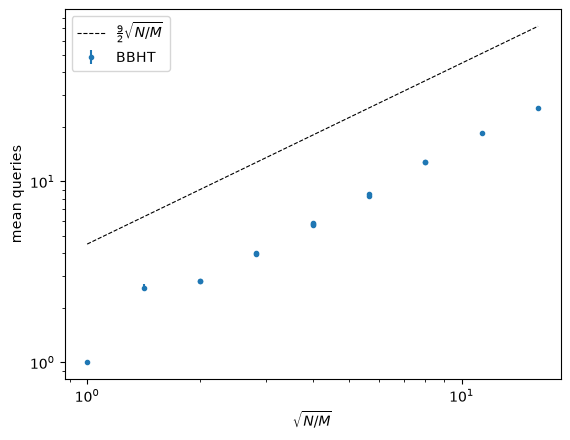

In [15]:
x = [math.sqrt(N / M) for N, M, _, _ in results]
plt.errorbar(x, [q[0] for *_, q in results], yerr=[q[1] for *_, q in results], fmt="o", ms=3, label="BBHT")
plt.plot(sorted(x), [9 / 2 * v for v in sorted(x)], "k--", lw=0.8, label=r"$\frac{9}{2}\sqrt{N/M}$")
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\sqrt{N/M}$")
plt.ylabel("mean queries")
plt.legend()
plt.show()

One complete schedule succeeds with probability close to $1$, much more than the guaranteed $1/4$: the bound is a worst case that considers only the last trial and uses the pessimistic estimate $1/4$ for it. The mean number of queries grows like $\sqrt{N/M}$; for $M=1$, quadrupling $N$ roughly doubles the number of queries, and the ratio is about $1.5$–$1.8$. This is well below the bound $\frac92\sqrt{N/M}$ on the expected number of Grover iterations. For large $M$ the one query for verification dominates, and the count approaches $1$ for $M=N$.

### Bounded procedure

In [16]:
runs = 200
for delta in [0.1, 0.01]:
    for N in [64, 256]:
        for M in [0, 1]:
            f = table(N, M)
            r = [bbht(f, budget(delta)) for _ in range(runs)]
            s = bernoulli(sum(x is None for x, _ in r), runs)
            q = mean([q for _, q in r])
            print(f"delta={delta:<4} L={budget(delta):2} N={N:3} M={M}  reports none={s[0]:.3f}±{s[1]:.3f}  queries={q[0]:6.2f}±{q[1]:.2f}")

delta=0.1  L= 9 N= 64 M=0  reports none=1.000±0.000  queries= 69.86±0.59


delta=0.1  L= 9 N= 64 M=1  reports none=0.000±0.000  queries= 11.83±0.46


delta=0.1  L= 9 N=256 M=0  reports none=1.000±0.000  queries=130.55±1.22


delta=0.1  L= 9 N=256 M=1  reports none=0.000±0.000  queries= 25.43±1.03


delta=0.01 L=17 N= 64 M=0  reports none=1.000±0.000  queries=106.15±0.69


delta=0.01 L=17 N= 64 M=1  reports none=0.000±0.000  queries= 13.38±0.54


delta=0.01 L=17 N=256 M=0  reports none=1.000±0.000  queries=202.28±1.35


delta=0.01 L=17 N=256 M=1  reports none=0.000±0.000  queries= 26.84±1.00


For $M=0$ the procedure always reports that no marked string exists, as it must, since every candidate is verified. It then performs all $\lceil\log_\lambda\lceil\sqrt N\rceil\rceil+L$ trials, so its cost grows with $\log(1/\delta)\sqrt N$. For $M=1$ we never observe a wrong "none". The error bound $\delta$ is again pessimistic: it ignores the trials before the cap and assumes success probability $1/4$ per capped trial, while the true success probability at the cap is close to $1/2$. Smaller $\delta$ increases the cost for $M=0$ considerably, but hardly for $M=1$, since the search usually ends before the cap.

## (d) Noisy simulation

Transpiled circuits for the studied instances:

In [17]:
for N, M in [(16, 1), (16, 4), (32, 1)]:
    f = table(N, M)
    for T in [1, 3, 5]:
        c = transpiled(f, T)
        print(f"N={N:2} M={M} T={T}  depth={c.depth():5}  cx={c.count_ops().get('cx', 0):4}")

N=16 M=1 T=1  depth=   55  cx=  28
N=16 M=1 T=3  depth=  163  cx=  84
N=16 M=1 T=5  depth=  271  cx= 140
N=16 M=4 T=1  depth=   50  cx=  26
N=16 M=4 T=3  depth=  148  cx=  78
N=16 M=4 T=5  depth=  246  cx= 130
N=32 M=1 T=1  depth=  131  cx=  72
N=32 M=1 T=3  depth=  391  cx= 216
N=32 M=1 T=5  depth=  651  cx= 360


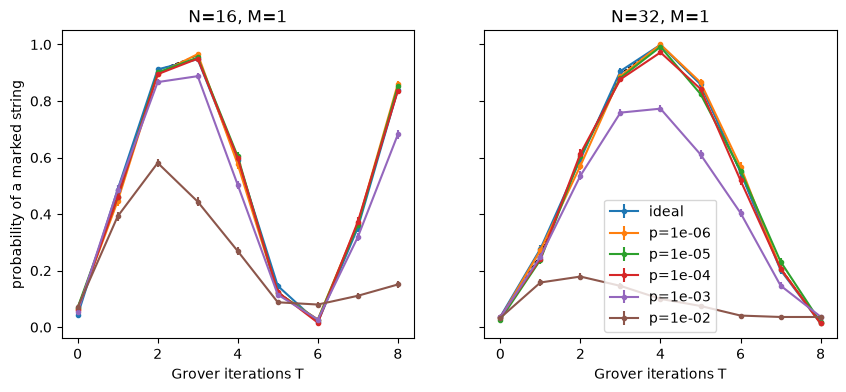

In [18]:
ps = [None] + [10.0**-k for k in range(6, 1, -1)]
shots, Ts = 1000, range(9)
fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for a, N in zip(ax, [16, 32]):
    f = table(N, 1)
    for p in ps:
        c = [bernoulli(sum(f[x] == "1" for x in run(f, T, shots, p)), shots) for T in Ts]
        a.errorbar(Ts, [r for r, _ in c], yerr=[s for _, s in c], marker="o", ms=3, label="ideal" if p is None else f"p={p:.0e}")
    a.plot(Ts, [P(T, 1, N) for T in Ts], "k--", lw=0.8)
    a.set_title(f"N={N}, M=1")
    a.set_xlabel("Grover iterations T")
ax[0].set_ylabel("probability of a marked string")
ax[1].legend()
plt.show()

For $p\leq10^{-4}$ the curves are indistinguishable from the ideal ones: the expected number of CX errors, $p$ times the CX count, is at most about $0.06$ for these circuits.

For larger $p$, a simple model explains the curves. Suppose that a run is error-free with probability $F_T$, and otherwise ends in the completely mixed state, which yields each string with probability $1/N$. Then
$$
P_{\text{noisy}}(T)\approx F_T\sin^2((2T+1)\theta)+(1-F_T)\,M/N.
$$
Ignoring one-qubit errors, $F_T\approx(1-p)^{cT}$, where $c$ is the number of CX gates per iteration; for $N=32$ we have $c=72$.

- $p=10^{-3}$, $T=4$: $F_4\approx0.999^{288}\approx0.75$, so $P\approx0.75\cdot1+0.25/32\approx0.76$; we measure about $0.77$.
- $p=10^{-2}$: one iteration is error-free only with probability $0.99^{72}\approx0.48$. At $T=2$, $F_2\approx0.23$ and $P\approx0.23\cdot0.60+0.77/32\approx0.16$; we measure about $0.18$. At the ideal optimum $T=4$, $F_4\approx0.05$ and $P\approx0.05\cdot1+0.95/32\approx0.08$; we measure about $0.10$.

The model is slightly pessimistic, since not every error completely scrambles the state, but it explains the behavior. The maximum drops below $0.2$ for $N=32$ (and below $0.6$ for $N=16$, with $c=28$), and it moves to fewer iterations: near its peak the ideal probability grows only slowly, while $F_T$ halves with every iteration. More iterations therefore do not always help, and for large $T$ the probability approaches $M/N$, the value of random guessing. Larger instances suffer more, since both the oracle and the number of iterations grow with $N$.

In [19]:
N, runs = 32, 300
for M in [1, 4]:
    f = table(N, M)
    for p in ps:
        r = [bbht(f, 1, p=p) for _ in range(runs)]
        s = bernoulli(sum(x is not None for x, _ in r), runs)
        q = mean([bbht(f, 10**9, p=p)[1] for _ in range(runs)])
        print(f"N={N} M={M} p={'ideal' if p is None else f'{p:.0e}':>6}  schedule success={s[0]:.3f}±{s[1]:.3f}  queries={q[0]:6.2f}±{q[1]:.2f}")

N=32 M=1 p= ideal  schedule success=0.993±0.005  queries=  8.34±0.27


N=32 M=1 p= 1e-06  schedule success=0.997±0.003  queries=  9.13±0.29


N=32 M=1 p= 1e-05  schedule success=0.987±0.007  queries=  8.84±0.30


N=32 M=1 p= 1e-04  schedule success=0.987±0.007  queries=  9.12±0.32


N=32 M=1 p= 1e-03  schedule success=0.997±0.003  queries=  9.14±0.34


...

N=32 M=4 p= 1e-06  schedule success=0.997±0.003  queries=  3.89±0.14


N=32 M=4 p= 1e-05  schedule success=1.000±0.000  queries=  4.03±0.15


N=32 M=4 p= 1e-04  schedule success=0.997±0.003  queries=  3.90±0.14


N=32 M=4 p= 1e-03  schedule success=0.997±0.003  queries=  4.47±0.19


N=32 M=4 p= 1e-02  schedule success=0.823±0.022  queries= 12.67±0.90


Up to $p=10^{-3}$ BBHT is essentially unaffected, although the fixed-$T$ success probability already drops at $p=10^{-3}$. BBHT makes many trials per schedule, verifies every candidate, and most of its trials use few iterations. So an error costs queries but never produces a wrong answer. At $p=10^{-2}$, one schedule succeeds with probability $0.68$ and the mean number of queries grows from about $8$ to $24$, more than the $(N+1)/(M+1)=16.5$ queries of classical search without replacement. BBHT remains correct, but noise has destroyed its advantage.

### Different marked sets with the same $M$

We fix $N=16$, $M=2$ and $T=2$ (close to optimal) and compare several marked sets, including the neighbors $\{0,1\}$.

In [20]:
N, M, T, shots = 16, 2, 2, 2000
fs = [table(N, M) for _ in range(5)] + ["11" + "0" * 14]
for f in fs:
    c = transpiled(f, T)
    r = [bernoulli(sum(f[x] == "1" for x in run(f, T, shots, p)), shots) for p in [1e-2, 1e-3]]
    S = [x for x in range(N) if f[x] == "1"]
    print(f"S={str(S):9} depth={c.depth():4} cx={c.count_ops().get('cx', 0):4}  " +
          "  ".join(f"p={p:.0e}: {a:.3f}±{b:.3f}" for p, (a, b) in zip([1e-2, 1e-3], r)))

S=[11, 12]  depth= 161 cx=  84  p=1e-02: 0.488±0.011  p=1e-03: 0.875±0.007
S=[9, 14]   depth= 161 cx=  84  p=1e-02: 0.486±0.011  p=1e-03: 0.881±0.007
S=[4, 14]   depth= 161 cx=  84  p=1e-02: 0.508±0.011  p=1e-03: 0.882±0.007
S=[4, 6]    depth=  79 cx=  40  p=1e-02: 0.682±0.010  p=1e-03: 0.913±0.006
S=[0, 1]    depth=  79 cx=  40  p=1e-02: 0.675±0.010  p=1e-03: 0.924±0.006
S=[0, 1]    depth=  79 cx=  40  p=1e-02: 0.676±0.010  p=1e-03: 0.922±0.006


The ideal success probability depends only on $M$, since the analysis only uses $\ket m$ and $\ket{\overline m}$, and $\ket u$ has the same angle $\theta$ to $\ket{\overline m}$ for every marked set of size $M$. The synthesized oracle, however, depends on the Boolean function. Two marked strings that differ in a single bit, such as $\{0,1\}$, which we included deliberately, form a cube, and the oracle becomes a single product term with $n-1$ literals. For $T=2$ this gives 40 instead of 84 CX gates. In the noisy simulation, the cheaper circuits succeed with a clearly higher probability at $p=10^{-2}$, and a slightly higher one at $p=10^{-3}$. With a minterm-by-minterm oracle (as in `qa-013`) the CX count would depend only on $M$. The difference comes from the synthesis of the oracle, not from the transpiler, since the barriers prevent optimization across the oracle boundary.

## (e) Classical baseline

Let $1\leq M\leq N$ and $Q$ be the number of queries until the first marked string is found.

**With replacement.** Every query independently finds a marked string with probability $M/N$, so $Q$ is geometrically distributed and $\mathbb E[Q]=N/M$.

**Without replacement.** The algorithm queries the strings in a uniformly random order. The $M$ marked strings divide the $N-M$ unmarked strings into $M+1$ gaps, and by symmetry each gap has the same expected size $(N-M)/(M+1)$. The first marked string follows the first gap, so
$$
\mathbb E[Q]=\frac{N-M}{M+1}+1=\frac{N+1}{M+1}.
$$
For $M\ll N$ both are $\Theta(N/M)$; sampling without replacement saves at most a factor of about $2$.

**Complexities.** Classically, a query at an unqueried string of a random instance finds a marked string with probability about $M/N$, so any classical algorithm needs $\Theta(N/M)$ queries in expectation. Grover search rotates by $2\theta$ per query with $\theta=\Theta(\sqrt{M/N})$, so $O(\sqrt{N/M})$ queries suffice, and BBHT achieves this without knowing $M$.

In [21]:
trials = 2000
classical_results = []
for N in [16, 64, 256, 1024]:
    for M in [1, 4, 16]:
        f = table(N, M)
        a = mean([classical(f, True) for _ in range(trials)])
        b = mean([classical(f, False) for _ in range(trials)])
        classical_results.append((N, M, a, b))
        print(f"N={N:4} M={M:2}  with={a[0]:7.2f}±{a[1]:.2f} (N/M={N/M:6.1f})  without={b[0]:7.2f}±{b[1]:.2f} ((N+1)/(M+1)={(N+1)/(M+1):6.1f})")

N=  16 M= 1  with=  15.49±0.33 (N/M=  16.0)  without=   8.37±0.10 ((N+1)/(M+1)=   8.5)
N=  16 M= 4  with=   4.10±0.08 (N/M=   4.0)  without=   3.31±0.05 ((N+1)/(M+1)=   3.4)


N=  16 M=16  with=   1.00±0.00 (N/M=   1.0)  without=   1.00±0.00 ((N+1)/(M+1)=   1.0)
N=  64 M= 1  with=  66.28±1.42 (N/M=  64.0)  without=  33.19±0.41 ((N+1)/(M+1)=  32.5)
N=  64 M= 4  with=  16.40±0.37 (N/M=  16.0)  without=  12.96±0.23 ((N+1)/(M+1)=  13.0)
N=  64 M=16  with=   3.85±0.08 (N/M=   4.0)  without=   3.73±0.07 ((N+1)/(M+1)=   3.8)


N= 256 M= 1  with= 257.07±5.74 (N/M= 256.0)  without= 126.59±1.68 ((N+1)/(M+1)= 128.5)
N= 256 M= 4  with=  65.25±1.42 (N/M=  64.0)  without=  52.08±0.93 ((N+1)/(M+1)=  51.4)
N= 256 M=16  with=  15.96±0.34 (N/M=  16.0)  without=  14.97±0.31 ((N+1)/(M+1)=  15.1)


N=1024 M= 1  with=1045.17±23.34 (N/M=1024.0)  without= 512.84±6.56 ((N+1)/(M+1)= 512.5)


N=1024 M= 4  with= 252.30±5.65 (N/M= 256.0)  without= 200.91±3.70 ((N+1)/(M+1)= 205.0)


N=1024 M=16  with=  64.31±1.42 (N/M=  64.0)  without=  59.91±1.28 ((N+1)/(M+1)=  60.3)


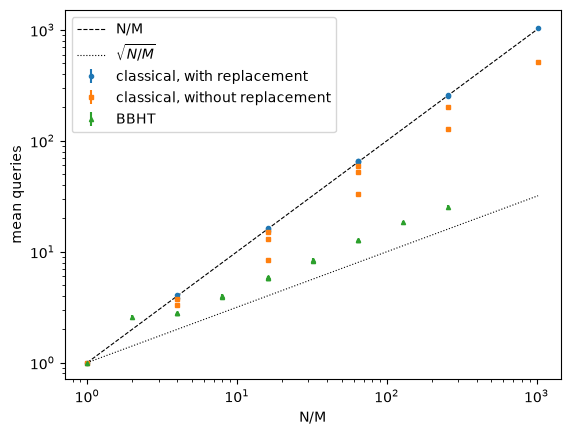

In [22]:
x = [N / M for N, M, _, _ in classical_results]
plt.errorbar(x, [a[0] for *_, a, _ in classical_results], yerr=[a[1] for *_, a, _ in classical_results], fmt="o", ms=3, label="classical, with replacement")
plt.errorbar(x, [b[0] for *_, b in classical_results], yerr=[b[1] for *_, b in classical_results], fmt="s", ms=3, label="classical, without replacement")
plt.errorbar([N / M for N, M, _, _ in results], [q[0] for *_, q in results], yerr=[q[1] for *_, q in results], fmt="^", ms=3, label="BBHT")
plt.plot(sorted(x), sorted(x), "k--", lw=0.8, label="N/M")
plt.plot(sorted(x), np.sqrt(sorted(x)), "k:", lw=0.8, label=r"$\sqrt{N/M}$")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("N/M")
plt.ylabel("mean queries")
plt.legend()
plt.show()

The classical measurements agree with $N/M$ and $(N+1)/(M+1)$. On the log-log plot the classical counts have slope $1$ and BBHT has slope $1/2$. For $N/M\leq4$ there is almost no difference, since one quantum trial already costs an iteration plus a verification. For $N=256$, $M=1$ BBHT uses about 26 queries instead of 128 (without replacement) or 256 (with replacement), and the gap grows as $\sqrt{N/M}$.